# Logistic Regression

Logistic Regression is used for **classification problems** where the data is linearly separable or almost linearly separable.

![](./images/img7.png)

---

In higher dimensions, the separation is done using **hyperplanes**.

---

## Example

Suppose we want to predict whether a student gets employment based on:

- CGPA
- IQ

We can separate the classes using a line:

$$
Ax_1 + Bx_2 + C = 0
$$

Where:

- \(x_1\) → CGPA
- \(x_2\) → IQ

---

If a data point lies on one side of the line, we classify it as one class.  
If it lies on the other side, we classify it as the other class.

---

## Goal

Our goal is to find appropriate values of:

$$
A, B, C
$$

so that the line separates the classes as accurately as possible.

![](./images/img7.png)

## Method 1: Perceptron Method

In the Perceptron Method:

- We start with random values of weights
- This gives a random decision boundary (line)

Instead of writing the line as:

$$
Ax_1 + Bx_2 + C = 0
$$

it is better to represent it as:

$$
w_0 + w_1x_1 + w_2x_2 = 0
$$

General form:

$$
\sum_{i=0}^{n} w_i x_i = 0
$$

---

## Prediction Rule

- If:

$$
\sum_{i=0}^{n} w_i x_i > 0
$$

prediction is class \(1\)

- Else:

$$
\sum_{i=0}^{n} w_i x_i < 0
$$

prediction is class \(0\)

---

## Positive and Negative Region

To determine which side of the line a point lies on, we substitute the point into the line equation.

For point \((x_1, x_2)\):

- If:

$$
Ax_1 + Bx_2 + C > 0
$$

the point lies in the positive region.

- Otherwise, it lies in the negative region.

---

## Transformations

The transformation is done by adjusting the weights.

### Step 1

Append \(1\) to the coordinate vector for bias handling.

Example:

$$
(x_1, x_2) \rightarrow (1, x_1, x_2)
$$

---

### Step 2

- If prediction is wrong and we need to move toward the positive region → add the point
- If prediction is wrong and we need to move toward the negative region → subtract the point

This update is too drastic, so we introduce a learning rate.

---

## Weight Update Rule

We multiply the coordinate vector with learning rate \(\eta\):

$$
w_{\text{new}}
=
w_{\text{old}}
-
\eta x_i
$$

or

$$
w_{\text{new}}
=
w_{\text{old}}
+
\eta x_i
$$

depending on the class prediction.

---

## Algorithm

```python
epoch = 1000
eta = 0.01

for i in range(epoch):

    randomly select a point

    check Σ(wixi)

    if prediction is positive:
        w_new = w_old - eta * xi

    else:
        w_new = w_old + eta * xi
```

## Simplified Update Rule

For simplification, we can combine both update cases into a single equation:

$$
w_{\text{new}}
=
w_{\text{old}}
+
\eta (y_i - \hat{y}_i)x_i
$$

Where:

- \(y_i\) = actual class
- \(\hat{y}_i\) = predicted class
- \(x_i\) = input vector
- \(\eta\) = learning rate

---

## Intuition

- If prediction is correct:

$$
y_i - \hat{y}_i = 0
$$

So weights do not change.

- If prediction is wrong:

$$
y_i - \hat{y}_i \neq 0
$$

Weights are updated in the correct direction.

---

## Simplified Algorithm

```python
epoch = 1000
eta = 0.01

for i in range(epoch):

    randomly select a point

    y_hat = prediction(xi)

    w = w + eta * (yi - y_hat) * xi

In [8]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

In [9]:
import matplotlib.pyplot as plt

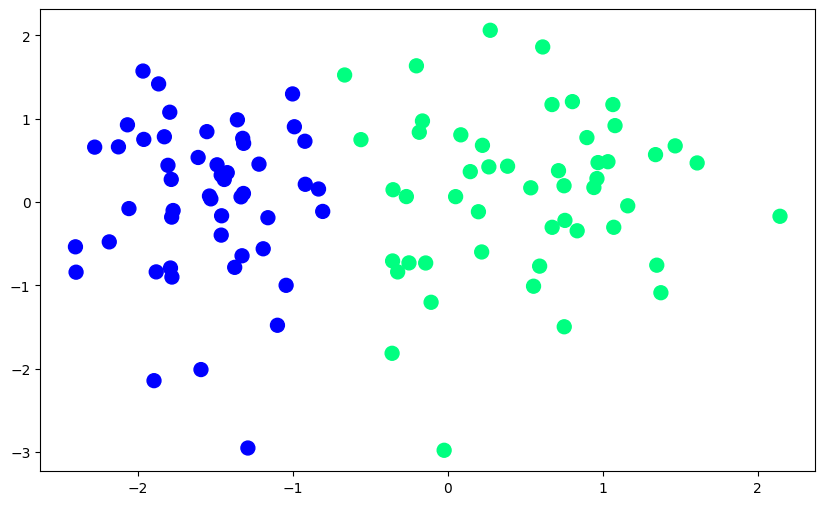

In [10]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [11]:
def perceptron(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]

In [12]:
def step(z):
    return 1 if z>0 else 0

In [13]:
def step(z):
    return 1 if z>0 else 0

In [14]:
intercept_,coef_ = perceptron(X,y)

In [15]:
print(coef_)
print(intercept_)

[1.26081891 0.13981514]
1.0


In [16]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [18]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

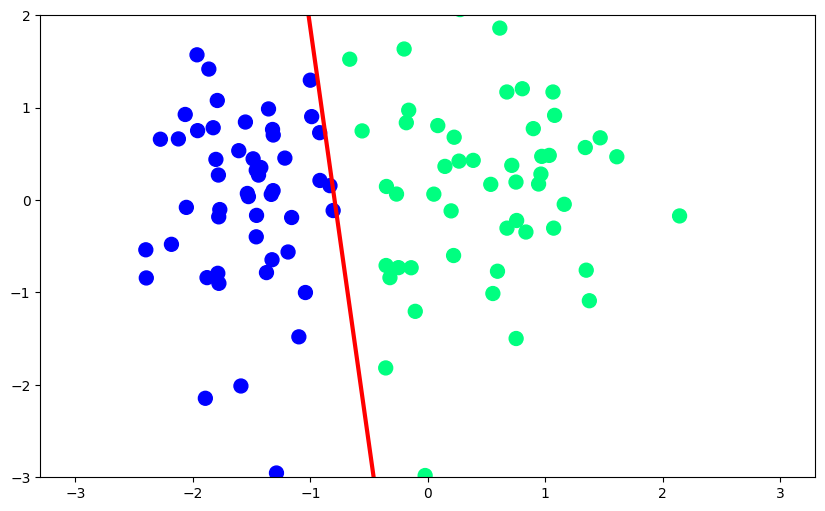

In [19]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [20]:
def perceptron(X,y):
    
    m = []
    b = []
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))
        
    return m,b

In [21]:
m,b = perceptron(X,y)

In [22]:
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

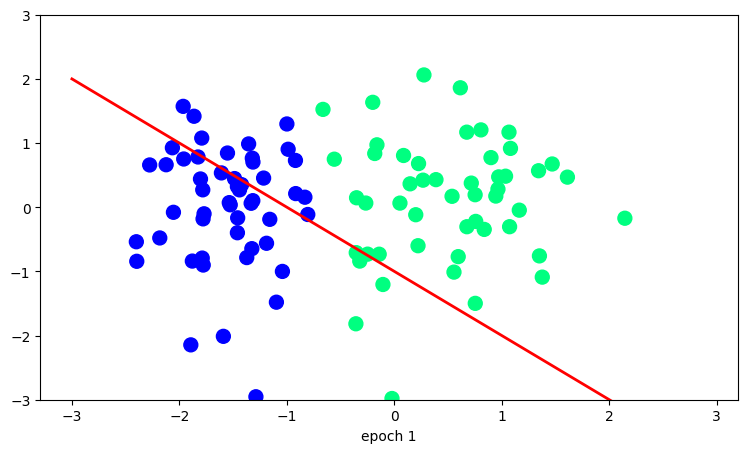

In [23]:
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] +b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] +b[0] , 'r-', linewidth=2)
plt.ylim(-3,3)
def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)

In [24]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [25]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

In [26]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

(-3.0, 2.0)

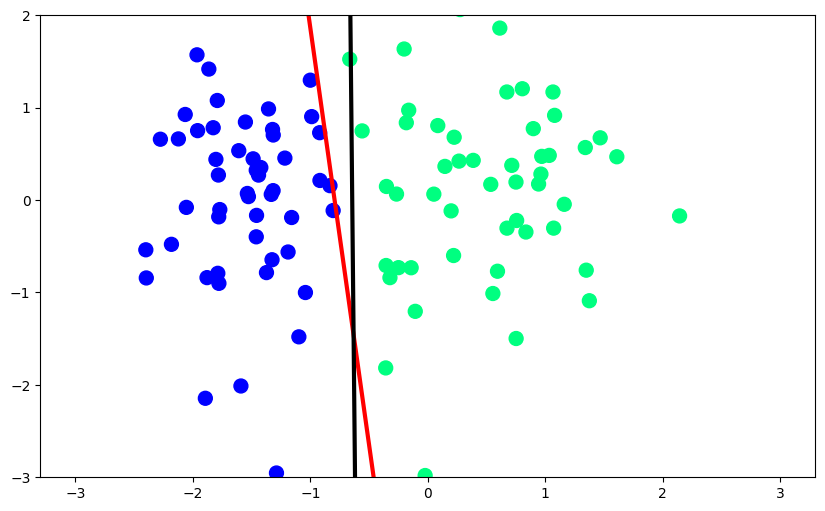

In [27]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

## Limitation of Perceptron Method

Perceptron uses the update rule:

$$
w_{\text{new}}
=
w_{\text{old}}
+
\eta (y_i - \hat{y}_i)x_i
$$

---

In this method:

- Only the misclassified points change the decision boundary
- Correctly classified points have no effect on the line

So only wrongly classified points pull the line toward themselves.

---

## Improved Idea

We modify the algorithm such that:

- Misclassified points pull the line closer
- Correctly classified points push the line further away

This helps create a larger margin between classes.

---

## Distance-Based Effect

The magnitude of push or pull depends on the distance of the point from the line.

### Misclassified Points

- If the point is far from the line → strong pull
- If the point is close to the line → weaker pull

### Correctly Classified Points

- If the point is close to the line → stronger push
- If the point is far from the line → weaker push

---

## Problem with Perceptron Output

In perceptron, predictions are only:

- \(0\)
- \(1\)

Thus errors become:

| Actual \(y_i\) | Predicted \(\hat{y}_i\) | Error \(y_i - \hat{y}_i\) |
|---|---|---|
| 1 | 1 | 0 |
| 0 | 0 | 0 |
| 1 | 0 | 1 |
| 0 | 1 | -1 |

For correctly classified points, the error becomes zero, so no update happens.

---

## Solution: Sigmoid Function

To solve this, Logistic Regression uses the sigmoid function instead of a hard step function.

:contentReference[oaicite:0]{index=0}

The sigmoid function converts any real value into a value between \(0\) and \(1\).

---

## Logistic Regression Prediction

First compute:

$$
z = \sum_{i=0}^{n} w_i x_i
$$

Then apply sigmoid:

$$
\hat{y} = \sigma(z)
$$

---

## Interpretation

- If output \(> 0.5\) → predict class \(1\)
- Else → predict class \(0\)

For points in the positive region, the output moves closer to \(1\).  
For points in the negative region, the output moves closer to \(0\).

Thus sigmoid gives a probabilistic interpretation.

---

## Example Errors

Now predictions are continuous values:

| Actual \(y_i\) | Predicted \(\hat{y}_i\) | Error \(y_i - \hat{y}_i\) |
|---|---|---|
| 1 | 0.8 | 0.2 |
| 0 | 0.65 | -0.65 |
| 1 | 0.3 | 0.7 |
| 0 | 0.15 | -0.15 |

---

## Final Update Rule

The update rule remains:

$$
w_{\text{new}}
=
w_{\text{old}}
+
\eta (y_i - \hat{y}_i)x_i
$$

But now the updates depend on the confidence and distance from the boundary for both correctly and incorrectly classified points.

In [28]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=30)

In [29]:
import matplotlib.pyplot as plt

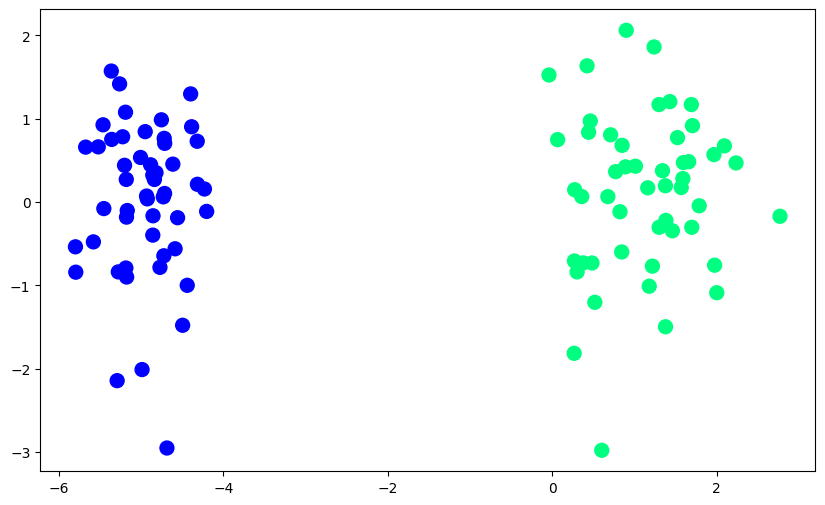

In [30]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [31]:
def perceptron(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]

In [32]:
def step(z):
    return 1 if z>0 else 0

In [33]:
intercept_,coef_ = perceptron(X,y)

In [34]:
print(coef_)
print(intercept_)

[1.1204053  0.40381514]
1.2000000000000002


In [35]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [36]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

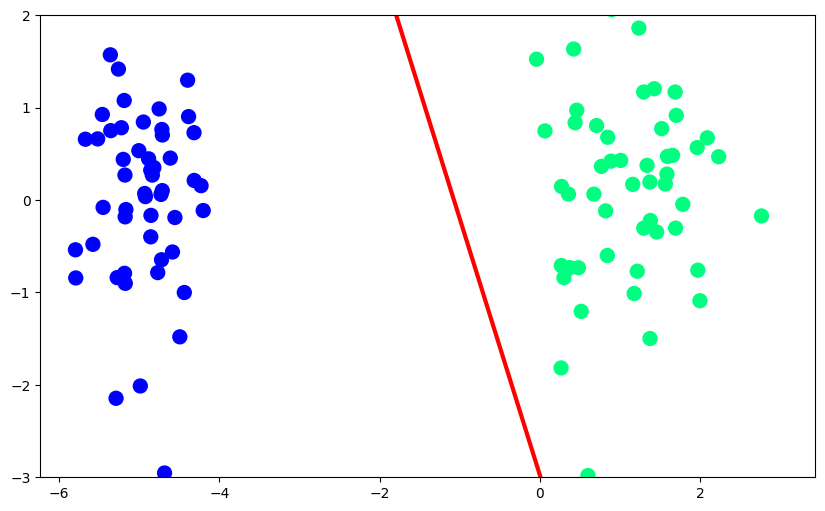

In [37]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [38]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [39]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

In [40]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

(-3.0, 2.0)

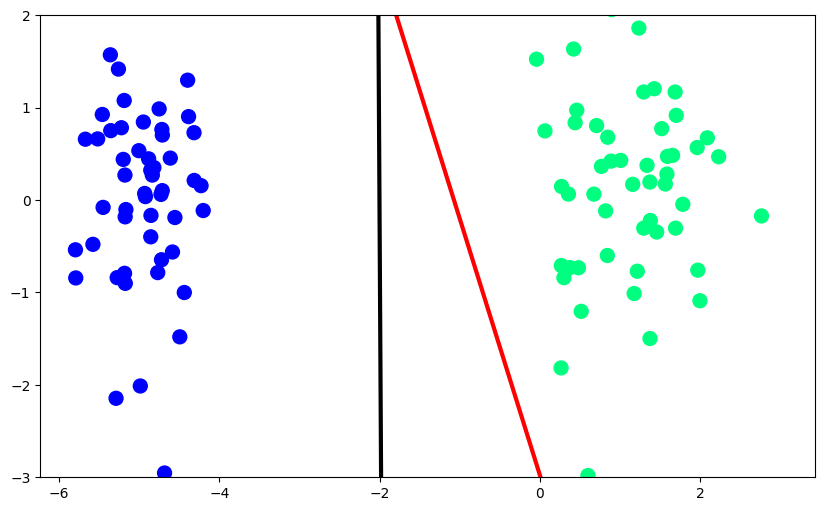

In [41]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [42]:
def perceptron(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = sigmoid(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]

In [43]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [44]:
intercept_,coef_ = perceptron(X,y)

In [45]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [46]:
x_input2 = np.linspace(-3,3,100)
y_input2 = m*x_input + b

(-3.0, 2.0)

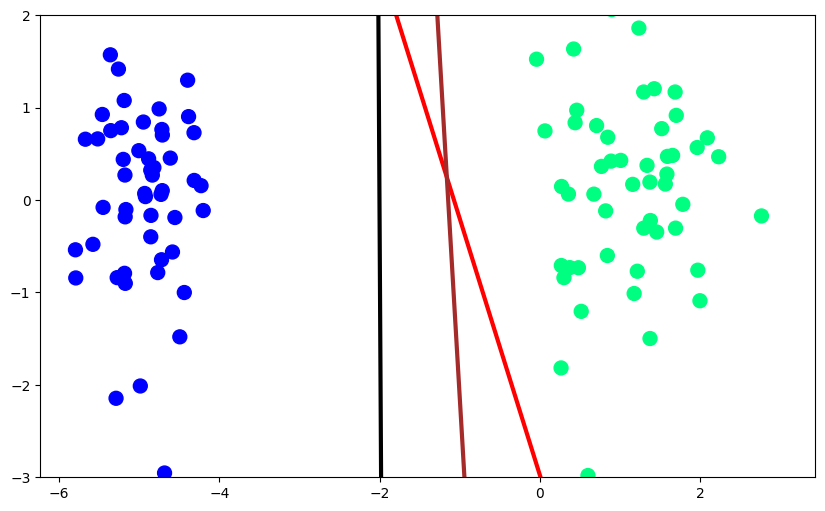

In [47]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.plot(x_input2,y_input2,color='brown',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

## Converting Likelihood to Loss Function

The likelihood function contains products:

$$
L = \prod_{i=1}^{n} \hat{y}_i^{y_i}(1-\hat{y}_i)^{(1-y_i)}
$$

Working with products is mathematically difficult, so we take logarithm.

Using log converts products into sums.

---

## Log Likelihood

Taking log:


$$
J(w) = -\frac{1}{n} \sum_{i=1}^{n}
\left[
y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i)
\right]
$$

---

## Negative Log Likelihood

Since probabilities lie between \(0\) and \(1\), their logarithm becomes negative.

So we multiply by negative sign and minimize the function.

This is called **Cross Entropy Loss** or **Log Loss**.

:contentReference[oaicite:0]{index=0}

---

## Goal

We need to minimize the cross entropy loss.

By minimizing this loss, Logistic Regression finds the best weights:

$$
w_0,w_1,w_2,\dots,w_n
$$

that maximize the likelihood of correct predictions. We minimize using Gradient Descent.

Let Data be

x11  x12   x13   ... x1n   y1  
x21  x22   x23   ... x2n   y2  
.  
.  
.  
xm1  xm2   xm3   ... xmn   ym  

---

## Model Parameters

We define weights:

w0, w1, w2, ..., wn

where:
- w0 → bias term
- w1...wn → feature weights

---

## Logistic Regression Hypothesis

For a single training example:

$$
\hat{y}_1 = \sigma(w_0 + w_1 x_{11} + w_2 x_{12} + w_3 x_{13} + \dots + w_n x_{1n})
$$

where σ is sigmoid.

---

## Vectorized Prediction

Instead of computing row by row, we stack everything:

$$
\hat{Y} =
\begin{bmatrix}
\hat{y}_1 \\
\hat{y}_2 \\
\vdots \\
\hat{y}_m
\end{bmatrix}
$$

which becomes:

$$
\hat{Y} = \sigma(XW)
$$

 This is the key idea that makes logistic regression scalable and efficient.

---

## Loss Function (Cross Entropy)

To measure how wrong our predictions are, we define:

$$
J(w) = -\frac{1}{m} \sum_{i=1}^{m}
\left[
y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i)
\right]
$$

---

## Matrix Form of Loss

More compactly:

$$
L = -\frac{1}{m} \left[
Y \log(\hat{Y}) + (1 - Y)\log(1 - \hat{Y})
\right]
$$

where:

$$
\hat{Y} = \sigma(XW)
$$

---

## Intuition (Important)

- If prediction is close to correct → loss is small  
- If prediction is very wrong → loss becomes large (penalized heavily)

This is why cross entropy works well for classification.

---

## Gradient Descent Setup

We initialize weights randomly:

$$
W =
\begin{bmatrix}
w_0 \\
w_1 \\
\vdots \\
w_n
\end{bmatrix}
$$

Then we iteratively update them to minimize loss.

---

## Gradient of Loss

After differentiation (chain rule through sigmoid + log loss):

$$
\frac{\partial L}{\partial W}
=
\frac{1}{m} X^T (\hat{Y} - Y)
$$

 This is one of the most important results in machine learning.

---

## Weight Update Rule

We move weights in the direction that reduces error:

$$
W = W - \eta \frac{1}{m} X^T (\hat{Y} - Y)
$$

or equivalently:

$$
W = W + \eta \frac{1}{m} X^T (Y - \hat{Y})
$$

---

## Dimensions Check (Always Good Practice)

$$
W \in \mathbb{R}^{(n+1)\times 1}
$$

$$
X \in \mathbb{R}^{m \times (n+1)}
$$

$$
Y, \hat{Y} \in \mathbb{R}^{m \times 1}
$$

So everything matches perfectly.

---

## Final Insight

Logistic regression is basically:

> Linear model + sigmoid + cross entropy + gradient descent

This combination makes it a simple yet extremely powerful classification algorithm.

In [56]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

In [57]:
import matplotlib.pyplot as plt

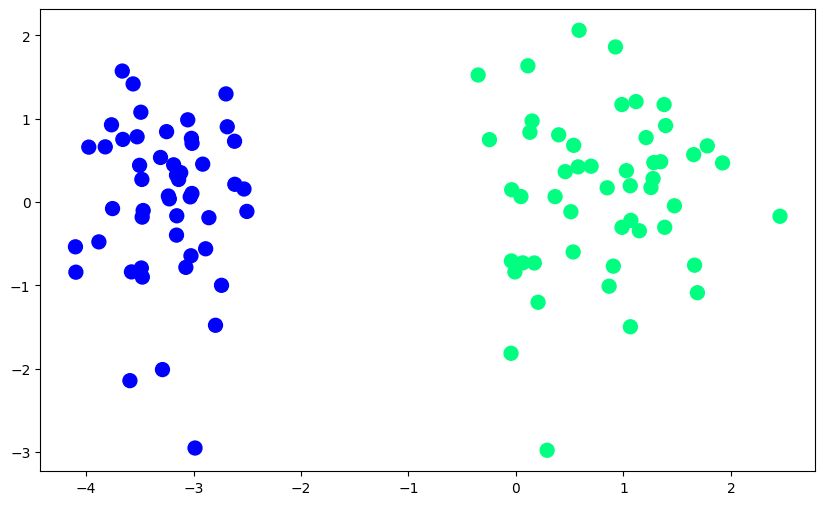

In [58]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [60]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(penalty=None,solver='sag')
lor.fit(X,y)

c:\Users\LENOVO\Desktop\Fusemachines AI Fellowship 2026\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\LENOVO\Desktop\Fusemachines AI Fellowship 2026\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [61]:
print(lor.coef_)
print(lor.intercept_)

[[4.86382589 0.2306822 ]]
[5.82716246]


In [62]:
m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1 = -(lor.intercept_/lor.coef_[0][1])

In [63]:
x_input = np.linspace(-3,3,100)
y_input = m1*x_input + b1

In [64]:
def gd(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.5
    
    for i in range(5000):
        y_hat = sigmoid(np.dot(X,weights))
        weights = weights + lr*(np.dot((y-y_hat),X)/X.shape[0])
        
    return weights[1:],weights[0]

In [65]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [66]:
coef_,intercept_ = gd(X,y)

In [67]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [68]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input1 + b

(-3.0, 2.0)

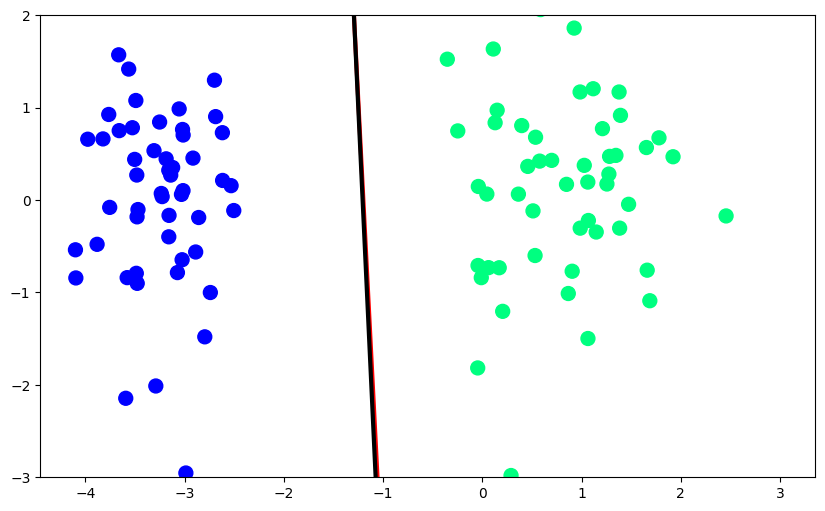

In [69]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)